# Three Buses, Three Weeks: What 416,000 GPS Pings Reveal About a Small-City Transit System

This notebook is a deep dive into `history.jsonl`, the append-only log produced by the
polling pipeline described in *[Reverse-Engineering My City's Bus Tracker](index.qmd)*.
Every 10–15 seconds a poller hit the Errachidia transit API for all three lines and
appended one snapshot of every live bus's position. The result is roughly **three weeks of
continuous GPS telemetry** for the city's entire bus fleet.

The raw file is humble — a timestamp and a list of `{line, bus, sens, lat, lng}` dicts per
line — but it implicitly encodes the *operational reality* of the network: when buses run,
how fast they move, where they slow down, how long they sit at the terminus, how reliable
the headways are, and how the fleet was deployed during (and after) the Eid holidays.

**What we'll extract:**

1. **Data quality** — polling cadence, outages, GPS freshness, fleet coverage.
2. **Temporal rhythm** — service hours, the weekday/hour heatmap, the Eid → full-service transition.
3. **Spatial structure** — the network drawn purely from pings, per-line extents, dwell hotspots.
4. **Speed & congestion** — in-motion speed, rush-hour slowdowns, the slowest street segments.
5. **Trips & runs** — segmenting the stream into one-way trips; durations, distances, daily counts.
6. **Service frequency** — real headways vs. the "low and unreliable" reputation.
7. **Stops & layovers** — dwell time per station, terminus layovers.
8. **Fleet operations** — vehicle↔line assignment, reassignments, per-bus utilization.

Everything below is computed from scratch using only `pandas`, `numpy`, and `matplotlib`.

## 0 · Setup

A handful of helpers we'll reuse: a vectorized haversine, a per-line colour map matching the
live site, and a small fix so latitude/longitude plots aren't horizontally distorted (one
degree of longitude is shorter than one degree of latitude away from the equator).

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Line metadata (ids, names, colours) mirror lines/*.json and the live map.
LINE_NAME  = {47: "L01", 48: "L02", 53: "L03"}
LINE_COLOR = {"L01": "#5BA8D9", "L02": "#7A4E2D", "L03": "#6DB56D"}
LINE_DESC  = {"L01": "Amazouj ↔ Meski",
              "L02": "Omrane ↔ Ahibous",
              "L03": "My Mhamed ↔ Tizegdalt"}
TZ_LOCAL = "Africa/Casablanca"  # Morocco, UTC+1 over this window

EARTH_R = 6_371_000.0  # metres

def haversine(lat1, lon1, lat2, lon2):
    # Great-circle distance in metres; fully vectorized over numpy arrays.
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dl   = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a))

def geo_aspect(ax, lat0):
    # Equal-distance aspect ratio for a lat/lng scatter at latitude lat0.
    ax.set_aspect(1.0 / np.cos(np.radians(lat0)))

print("ready")

ready


## 1 · Loading & tidying

The file is one JSON object per line: a `fetched_at` ISO timestamp and a `buses` list. We
make **two** tables in a single pass, because they answer different questions:

- **`snaps`** — one row per *poll* (including the ~31% of polls that returned **no** buses).
  This is the full collection timeline; we need the empty polls to study cadence, outages and
  service hours honestly.
- **`df`** — one row per *bus sighting* (~416 k rows). This is the movement data.

Two small cleanups while loading:

- The earliest records (the original single-line L02 experiment, before the multi-line poller)
  carry **no** `line` field. Those sightings are all vehicle `12203` on L02, so we backfill
  `line = 48`.
- Timestamps are parsed as UTC and a `local` column is added in Morocco time (UTC+1) — the
  timezone trap called out in the article. The bus-side `src_updated_at` is UTC.

In [ ]:
# Resolve the data file whether it sits next to the notebook or under data/.
CANDIDATES = [Path("history.jsonl"), Path("data/history.jsonl")]
HIST = next((p for p in CANDIDATES if p.exists()), None)
assert HIST is not None, f"history.jsonl not found in {[str(c) for c in CANDIDATES]}"
print("reading", HIST.resolve())

snap_rows = []   # (fetched_at, n_buses)
bus_rows  = []   # (fetched_at, line, bus, sens, lat, lng, src_updated_at)
with HIST.open(encoding="utf-8") as f:
    for raw in f:
        raw = raw.strip()
        if not raw:
            continue
        o = json.loads(raw)
        fa = o["fetched_at"]
        buses = o.get("buses", [])
        snap_rows.append((fa, len(buses)))
        for b in buses:
            bus_rows.append((fa, b.get("line"), b.get("bus"), b.get("sens"),
                             b["lat"], b["lng"], b.get("src_updated_at")))

snaps = pd.DataFrame(snap_rows, columns=["fetched_at", "n_buses"])
df = pd.DataFrame(bus_rows, columns=["fetched_at", "line", "bus", "sens",
                                     "lat", "lng", "src_updated_at"])

for d in (snaps, df):
    d["fetched_at"] = pd.to_datetime(d["fetched_at"], utc=True)

# Backfill the pre-multi-line records (all vehicle 12203 on L02 = line 48).
df["line"] = df["line"].fillna(48).astype(int)
df["line_name"] = df["line"].map(LINE_NAME)
df["src_updated_at"] = pd.to_datetime(df["src_updated_at"], utc=True, errors="coerce")

# Local (Morocco) wall-clock views.
snaps["local"] = snaps["fetched_at"].dt.tz_convert(TZ_LOCAL)
df["local"]    = df["fetched_at"].dt.tz_convert(TZ_LOCAL)
df["date"]     = df["local"].dt.date
df["hour"]     = df["local"].dt.hour
df["dow"]      = df["local"].dt.dayofweek           # 0 = Monday
snaps["date"]  = snaps["local"].dt.date
snaps["hour"]  = snaps["local"].dt.hour
snaps["dow"]   = snaps["local"].dt.dayofweek

print(f"{len(snaps):,} polls   |   {len(df):,} bus sightings")
df.head()

reading D:\Projects\personal_blog\posts\err-bus\history.jsonl


114,454 polls   |   416,552 bus sightings


,fetched_at,line,bus,sens,lat,lng,src_updated_at,line_name,local,date,hour,dow
0,2026-05-30 16:12:11.297955+00:00,48,12203,0,31.88316,-4.3552,2026-05-30 16:12:05+00:00,L02,2026-05-30 17:12:11.297955+01:00,2026-05-30,17,5
1,2026-05-30 16:12:21.767045+00:00,48,12203,0,31.88316,-4.3552,2026-05-30 16:12:15+00:00,L02,2026-05-30 17:12:21.767045+01:00,2026-05-30,17,5
2,2026-05-30 16:12:32.114726+00:00,48,12203,0,31.88316,-4.3552,2026-05-30 16:12:25+00:00,L02,2026-05-30 17:12:32.114726+01:00,2026-05-30,17,5
3,2026-05-30 16:12:42.494205+00:00,48,12203,0,31.88316,-4.3552,2026-05-30 16:12:35+00:00,L02,2026-05-30 17:12:42.494205+01:00,2026-05-30,17,5
4,2026-05-30 16:12:52.922420+00:00,48,12203,0,31.88316,-4.3552,2026-05-30 16:12:46+00:00,L02,2026-05-30 17:12:52.922420+01:00,2026-05-30,17,5


## 2 · The dataset at a glance

Before any analysis, a census: how long the window is, how many vehicles, and how the
sightings split across the three lines.

In [ ]:
span = df["fetched_at"].max() - df["fetched_at"].min()
print("Coverage window (UTC)")
print("  first poll :", snaps['fetched_at'].min())
print("  last  poll :", snaps['fetched_at'].max())
print(f"  span       : {span.days} days, {span.seconds//3600} h")
print(f"  polls      : {len(snaps):,}  ({(snaps['n_buses']==0).mean()*100:.1f}% returned no buses)")
print(f"  sightings  : {len(df):,}")
print(f"  vehicles   : {df['bus'].nunique()}  ->  {sorted(df['bus'].unique())}")
print()

by_line = (df.groupby("line_name")
             .agg(sightings=("bus", "size"),
                  vehicles=("bus", "nunique"),
                  first=("local", "min"),
                  last=("local", "max"))
             .assign(share=lambda t: (t["sightings"] / t["sightings"].sum() * 100).round(1)))
by_line["route"] = by_line.index.map(LINE_DESC)
by_line[["route", "sightings", "share", "vehicles"]]

Coverage window (UTC)
  first poll : 2026-05-30 16:12:11.297955+00:00
  last  poll : 2026-06-18 22:22:27.438291+00:00
  span       : 19 days, 6 h
  polls      : 114,454  (30.9% returned no buses)
  sightings  : 416,552
  vehicles   : 6  ->  ['12101', '12201', '12202', '12203', '12301', '12304']



,route,sightings,share,vehicles
line_name,,,,
L01,Amazouj ↔ Meski,206004,49.5,4
L02,Omrane ↔ Ahibous,76738,18.4,2
L03,My Mhamed ↔ Tizegdalt,133810,32.1,2


L01 dominates the sightings — it has more assigned vehicles and the longest continuous
coverage — while L02 (the line the project started with) is comparatively thin because it ran
alone, with a single bus, during the early Eid period before the other lines were added.

## 3 · Data quality & collection reliability

Any insight is only as trustworthy as the collection process. Four checks: how regular the
polling was, where it dropped out, how fresh the GPS fixes were, and how complete the fleet
coverage was per poll.

### 3.1 Polling cadence

The poller's loop sleeps a fixed interval between requests, but each cycle also makes three
HTTP calls (one per line), so the *effective* spacing wanders. Plotting the gap between
consecutive polls shows two clean regimes — the **10 s** default and a **15 s** setting — plus
a thin tail from network latency.

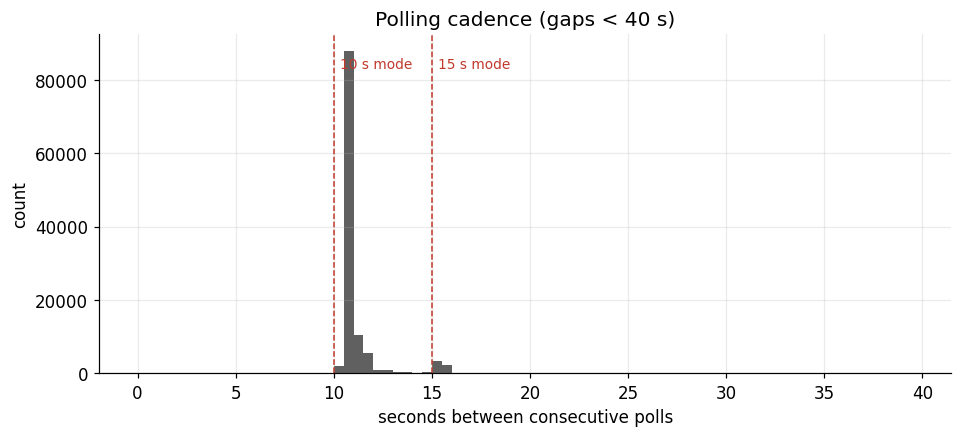

median gap   : 10.88 s
p95 gap      : 15.19 s
effective rate: ~1 poll / 11 s  =>  ~7,944 polls/day at full uptime


In [ ]:
ts = snaps["fetched_at"].sort_values()
dt = ts.diff().dt.total_seconds().dropna()
normal = dt[dt < 40]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal, bins=np.arange(0, 40, 0.5), color="#444", alpha=0.85)
for x, lbl in [(10, "10 s mode"), (15, "15 s mode")]:
    ax.axvline(x, color="#c0392b", ls="--", lw=1)
    ax.text(x + 0.3, ax.get_ylim()[1]*0.9, lbl, color="#c0392b", fontsize=9)
ax.set(xlabel="seconds between consecutive polls", ylabel="count",
       title="Polling cadence (gaps < 40 s)")
plt.show()

print(f"median gap   : {dt.median():.2f} s")
print(f"p95 gap      : {dt.quantile(0.95):.2f} s")
print(f"effective rate: ~1 poll / {dt.median():.0f} s  =>  ~{86400/dt.median():,.0f} polls/day at full uptime")

### 3.2 Outages

Almost every gap is ~10–15 s. The handful of large ones are real downtime — the polling
machine was off or offline. Listing every gap over 5 minutes gives the outage ledger.

In [ ]:
gap_s = ts.diff().dt.total_seconds()
big = pd.DataFrame({"gap_s": gap_s, "resumed": ts}).dropna()
big["started"] = big["resumed"] - pd.to_timedelta(big["gap_s"], unit="s")
big = big[big["gap_s"] > 300].sort_values("gap_s", ascending=False)
out = big.assign(
    hours=(big["gap_s"]/3600).round(2),
    outage_start=big["started"].dt.tz_convert(TZ_LOCAL).dt.strftime("%a %m-%d %H:%M"),
    came_back=big["resumed"].dt.tz_convert(TZ_LOCAL).dt.strftime("%a %m-%d %H:%M"),
)[["outage_start", "came_back", "hours"]]

uptime_lost = big["gap_s"].sum()
total_span  = (ts.max() - ts.min()).total_seconds()
print(f"{len(big)} outages > 5 min;  {uptime_lost/3600:.1f} h lost  "
      f"({uptime_lost/total_span*100:.1f}% of the window)")
out.reset_index(drop=True)

3 outages > 5 min;  105.3 h lost  (22.8% of the window)


,outage_start,came_back,hours
0,Fri 06-05 10:23,Mon 06-08 16:52,78.49
1,Wed 06-10 05:00,Wed 06-10 19:13,14.22
2,Sat 05-30 23:24,Sun 05-31 12:01,12.63


The dominant outage is a ~3.3-day stretch in early June — almost all of the lost time sits in
that single window. Outside it, the feed is remarkably continuous for a hobby poller running
on a personal machine.

### 3.3 GPS freshness

Each sighting carries the API's own `src_updated_at` (when the bus last reported) alongside
our `fetched_at` (when we polled). Their difference is the **age** of the fix at capture time.
If the GPS updates on a similar ~10 s cadence and clocks agree, ages should spread roughly
uniformly over a short window — which is exactly what we see, confirming `src_updated_at` is
UTC (the article's timezone cross-check).

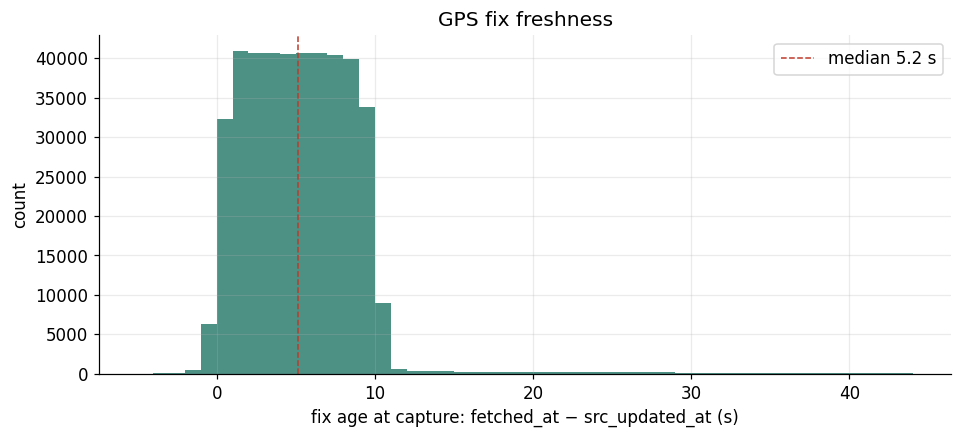

median age : 5.2 s   |   p95 : 9.9 s   |   p99 : 40.1 s
negative (minor clock skew): 1.7% of fixes, min -21.4 s


In [ ]:
age = (df["fetched_at"] - df["src_updated_at"]).dt.total_seconds().dropna()
core = age[(age > -30) & (age < 60)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(core, bins=np.arange(-5, 45, 1), color="#2e7d6f", alpha=0.85)
ax.axvline(age.median(), color="#c0392b", ls="--", lw=1,
           label=f"median {age.median():.1f} s")
ax.set(xlabel="fix age at capture: fetched_at − src_updated_at (s)",
       ylabel="count", title="GPS fix freshness")
ax.legend()
plt.show()

print(f"median age : {age.median():.1f} s   |   p95 : {age.quantile(0.95):.1f} s   |   p99 : {age.quantile(0.99):.1f} s")
print(f"negative (minor clock skew): {(age < 0).mean()*100:.1f}% of fixes, min {age.min():.1f} s")

### 3.4 Fleet coverage per poll

How many of the (up to six) buses were live in each poll? This blends two things: the
day/night service cycle and whether the full fleet was deployed.

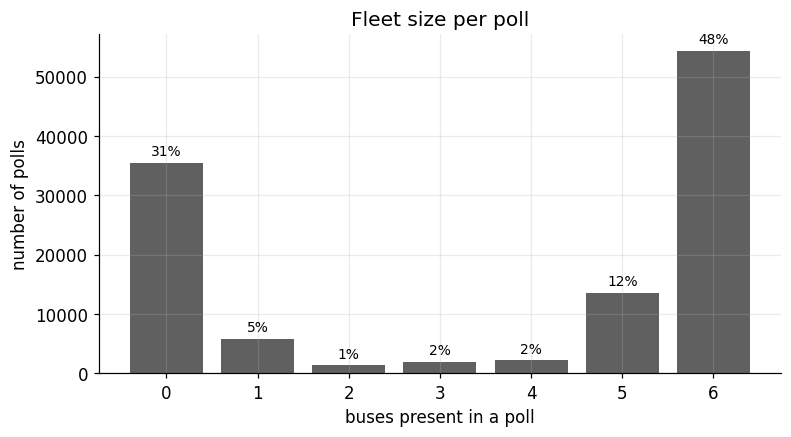

Most common states: all-6 fleet (daytime full service) and 0 (overnight).


In [ ]:
counts = snaps["n_buses"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color="#444", alpha=0.85)
ax.bar_label(bars, labels=[f"{v/len(snaps)*100:.0f}%" for v in counts.values], padding=3, fontsize=9)
ax.set(xlabel="buses present in a poll", ylabel="number of polls",
       title="Fleet size per poll", xticks=range(0, 7))
plt.show()

print("Most common states: all-6 fleet (daytime full service) and 0 (overnight).")

## 4 · When do the buses run?

### 4.1 Service window

Counting polls that returned at least one bus, by local hour, draws the daily service
envelope: a sharp start, a long plateau, and a wind-down at night.

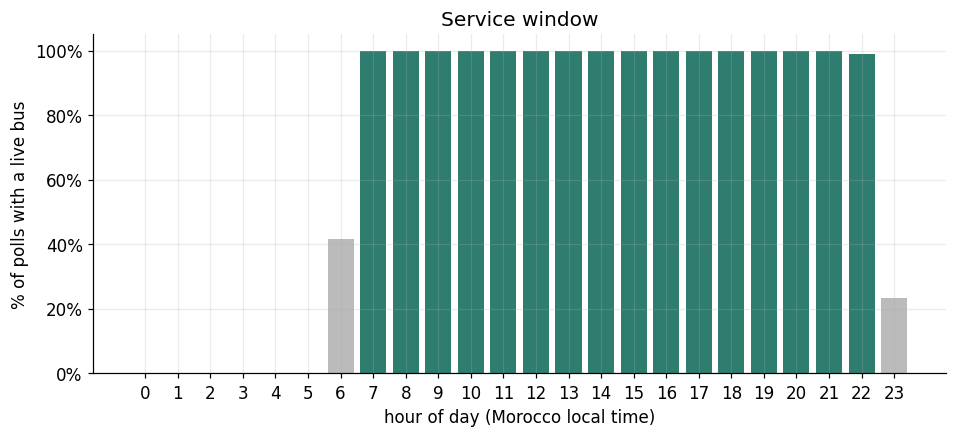

Core service: ~07:00 to ~23:00 local.
Ramp-up at 06:00, wind-down through 23:00, effectively nothing 00:00-05:00.


In [ ]:
snaps["active"] = snaps["n_buses"] > 0
hourly = snaps.groupby("hour")["active"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color=["#bbb" if v < 50 else "#2e7d6f" for v in hourly.values])
ax.set(xlabel="hour of day (Morocco local time)", ylabel="% of polls with a live bus",
       title="Service window", xticks=range(0, 24))
ax.yaxis.set_major_formatter(PercentFormatter())
plt.show()

active_hours = hourly[hourly > 50].index
print(f"Core service: ~{active_hours.min():02d}:00 to ~{active_hours.max()+1:02d}:00 local.")
print("Ramp-up at 06:00, wind-down through 23:00, effectively nothing 00:00-05:00.")

### 4.2 Weekly rhythm

Averaging the number of live buses across each (weekday, hour) cell shows how deployment
varies through the week. Friday — with midday prayers — and the weekend are worth watching in
a Moroccan city.

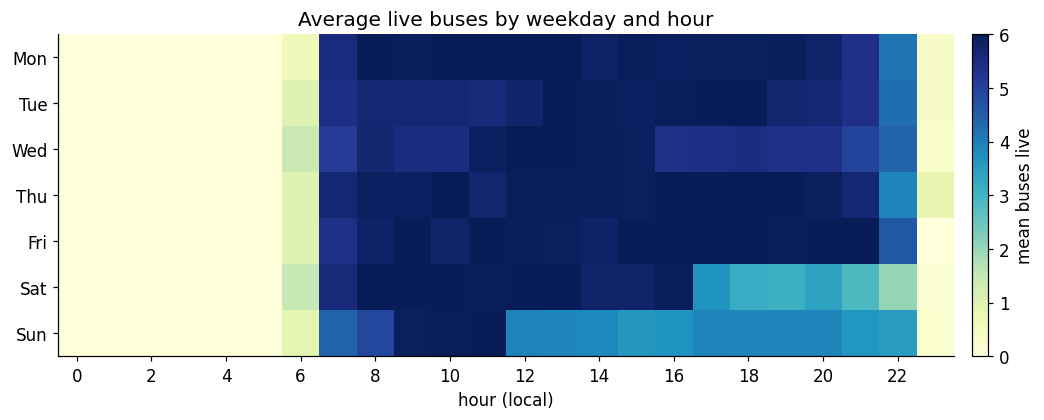

In [ ]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = (snaps.groupby(["dow", "hour"])["n_buses"].mean()
              .unstack("hour").reindex(index=range(7), columns=range(24)))

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu", origin="upper",
               extent=[-0.5, 23.5, 6.5, -0.5], vmin=0)
ax.set(yticks=range(7), xticks=range(0, 24, 2),
       xlabel="hour (local)", ylabel="",
       title="Average live buses by weekday and hour")
ax.set_yticklabels(DOW)
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("mean buses live")
plt.show()

### 4.3 The Eid ramp-up

A timeline of the live fleet (resampled to 30-minute means) tells the operational story of
the window: the project opens during the Eid al-Adha holidays with a **single** bus
shuttling on L02, the full six-vehicle fleet phases in once normal service resumes, and the
early-June outage shows up as a flat gap.

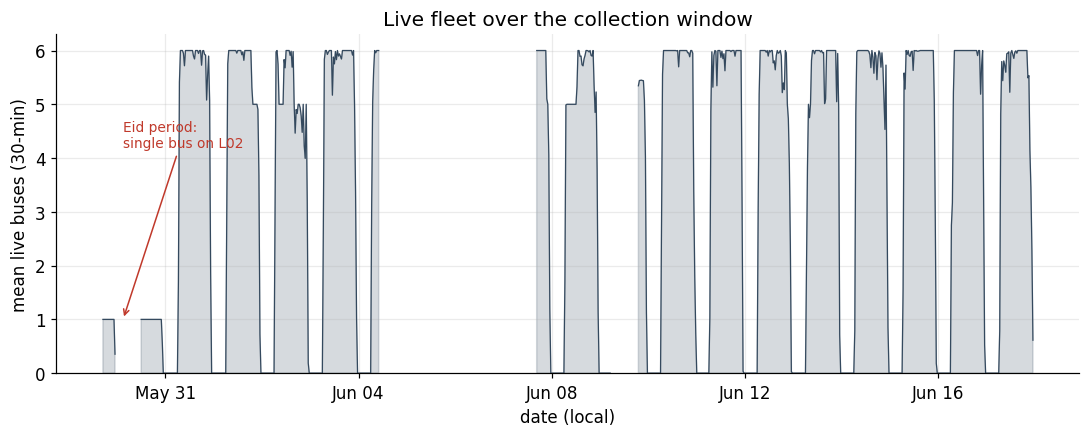

In [ ]:
fleet = (snaps.set_index("local")["n_buses"]
              .resample("30min").mean())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fleet.index, fleet.values, lw=0.8, color="#34495e")
ax.fill_between(fleet.index, fleet.values, color="#34495e", alpha=0.2)
ax.set(xlabel="date (local)", ylabel="mean live buses (30-min)",
       title="Live fleet over the collection window", ylim=(0, 6.3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.annotate("Eid period:\nsingle bus on L02", xy=(fleet.index[20], 1),
            xytext=(fleet.index[20], 4.2), fontsize=9, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))
plt.show()

## 5 · Where do the buses go?

### 5.1 The network, drawn from pings alone

No basemap, no route definitions — just every GPS fix coloured by line. The three routes,
their shared downtown trunk, and the terminus stubs emerge directly from the data. Station
locations (from `stations.json`) are overlaid.

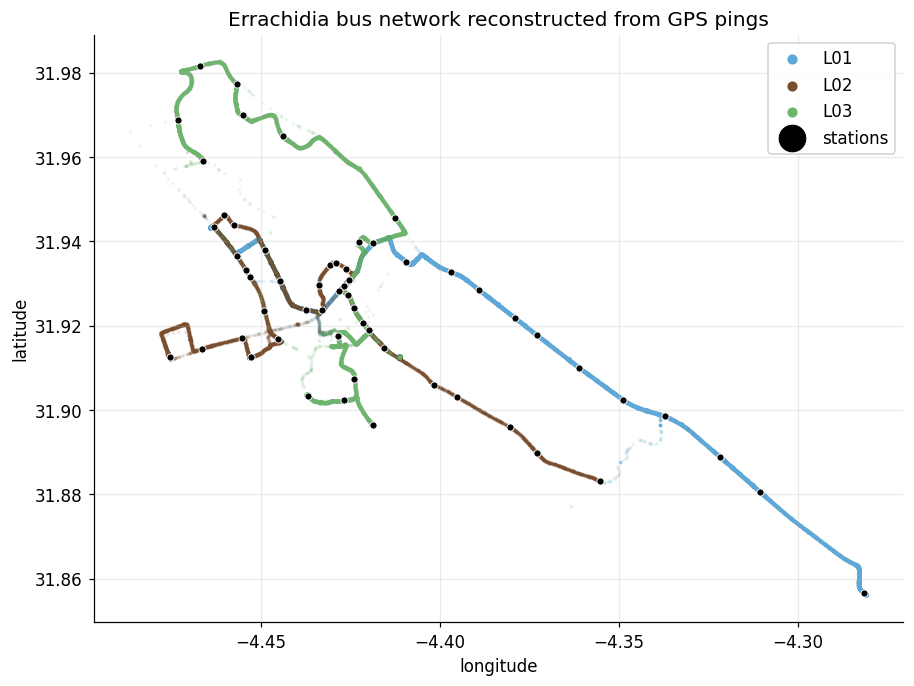

In [ ]:
stations = json.load(open("stations.json", encoding="utf-8"))
st_lat = np.array([s["lat"] for s in stations])
st_lng = np.array([s["lng"] for s in stations])
lat0 = df["lat"].median()

samp = df.sample(min(90_000, len(df)), random_state=0)
fig, ax = plt.subplots(figsize=(9.5, 8))
for ln in ["L01", "L02", "L03"]:
    s = samp[samp["line_name"] == ln]
    ax.scatter(s["lng"], s["lat"], s=2, alpha=0.08, color=LINE_COLOR[ln], label=ln)
ax.scatter(st_lng, st_lat, s=22, color="black", marker="o", zorder=5,
           edgecolor="white", linewidth=0.6, label="stations")
geo_aspect(ax, lat0)
ax.set(xlabel="longitude", ylabel="latitude",
       title="Errachidia bus network reconstructed from GPS pings")
leg = ax.legend(markerscale=4, framealpha=0.9)
for lh in leg.legend_handles[:3]:
    lh.set_alpha(1)
plt.show()

### 5.2 Per-line spatial extent

A quick numeric summary of each route's footprint — bounding box span in kilometres — gives a
sense of how far each line reaches.

In [ ]:
def span_km(g):
    dlat = haversine(g["lat"].min(), g["lng"].mean(), g["lat"].max(), g["lng"].mean())
    dlng = haversine(g["lat"].mean(), g["lng"].min(), g["lat"].mean(), g["lng"].max())
    return pd.Series({"N-S span (km)": dlat/1000, "E-W span (km)": dlng/1000})

extent = df.groupby("line_name").apply(span_km, include_groups=False).round(2)
extent["route"] = extent.index.map(LINE_DESC)
extent[["route", "N-S span (km)", "E-W span (km)"]]

,route,N-S span (km),E-W span (km)
line_name,,,
L01,Amazouj ↔ Meski,10.04,18.60
L02,Omrane ↔ Ahibous,8.21,16.86
L03,My Mhamed ↔ Tizegdalt,9.61,7.26


### 5.3 Dwell hotspots

A 2-D histogram of *where buses sit still* (consecutive fixes < 5 m apart). Bright cells are
the places a bus spends real time stationary: termini, the bus station, and major junctions.
We compute movement first since several later sections reuse it.

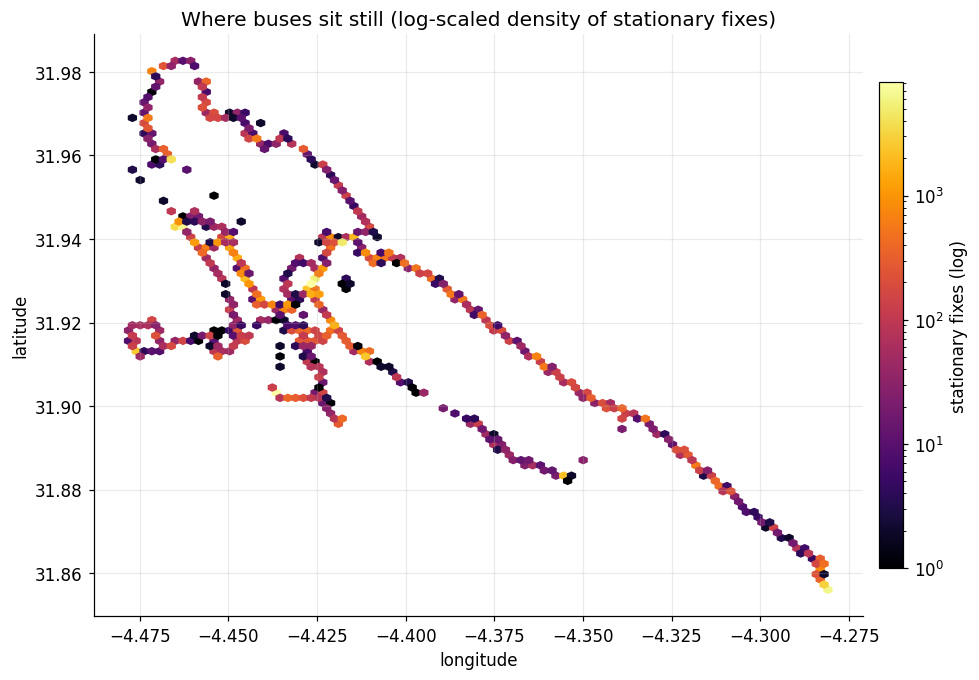

In [ ]:
# --- movement: per-vehicle consecutive-fix distance, dt, speed -----------
df = df.sort_values(["bus", "fetched_at"]).reset_index(drop=True)
g = df.groupby("bus", sort=False)
df["dt"] = g["fetched_at"].diff().dt.total_seconds()
df["step_m"] = haversine(g["lat"].shift(), g["lng"].shift(), df["lat"], df["lng"])

# A "track" segment is a within-vehicle step with a sane time gap.
on_track = (df["dt"] > 0) & (df["dt"] <= 60)
df["speed_kmh"] = np.where(on_track, df["step_m"] / df["dt"] * 3.6, np.nan)
GPS_JUMP = 80  # km/h: implausible for a city bus -> GPS teleport
df["moving"] = df["speed_kmh"] > 4
df["stationary"] = on_track & (df["step_m"] < 5)

stat = df[df["stationary"]]
fig, ax = plt.subplots(figsize=(9.5, 8))
hb = ax.hexbin(stat["lng"], stat["lat"], gridsize=90, cmap="inferno",
               bins="log", mincnt=1)
geo_aspect(ax, lat0)
ax.set(xlabel="longitude", ylabel="latitude",
       title="Where buses sit still (log-scaled density of stationary fixes)")
fig.colorbar(hb, ax=ax, fraction=0.03, pad=0.02, label="stationary fixes (log)")
plt.show()

## 6 · How fast, and where does it slow down?

### 6.1 Speed distribution

Instantaneous speed from consecutive fixes. Including stops, the distribution is dominated by
near-zero values (dwelling at stations and lights); among *moving* fixes (> 4 km/h) the modal
cruising speed sits in a typical urban-arterial band. Fixes implying > 80 km/h are treated as
GPS jumps and excluded.

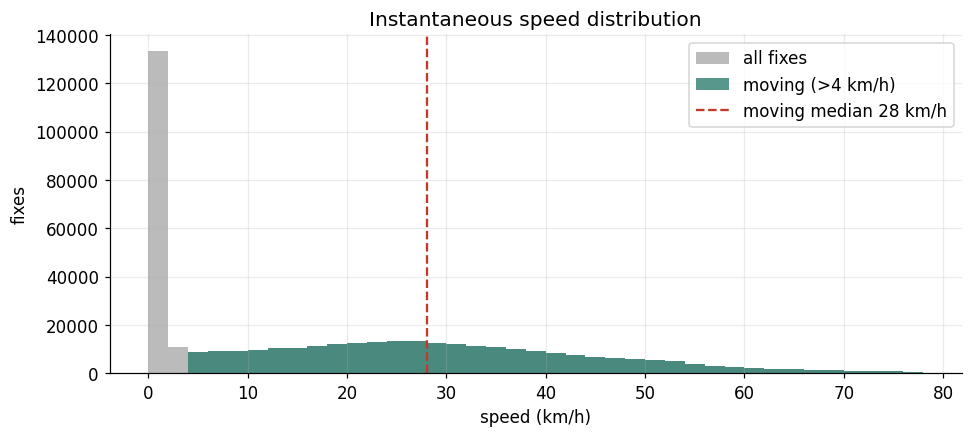

share of fixes effectively stopped (<4 km/h): 35%
GPS jumps discarded (>80 km/h): 6,285 fixes


In [ ]:
valid = df["speed_kmh"].between(0, GPS_JUMP)
allspd = df.loc[valid, "speed_kmh"]
movspd = df.loc[valid & df["moving"], "speed_kmh"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(allspd, bins=np.arange(0, 80, 2), color="#bbb", label="all fixes")
ax.hist(movspd, bins=np.arange(0, 80, 2), color="#2e7d6f", alpha=0.8, label="moving (>4 km/h)")
ax.axvline(movspd.median(), color="#c0392b", ls="--",
           label=f"moving median {movspd.median():.0f} km/h")
ax.set(xlabel="speed (km/h)", ylabel="fixes", title="Instantaneous speed distribution")
ax.legend()
plt.show()

print(f"share of fixes effectively stopped (<4 km/h): {(allspd < 4).mean()*100:.0f}%")
print(f"GPS jumps discarded (>{GPS_JUMP} km/h): {(df['speed_kmh'] > GPS_JUMP).sum():,} fixes")

### 6.2 Rush-hour effect

Average **moving** speed by hour of day. If congestion bites, mid-morning and evening peaks
should dip below the free-flowing early and late hours.

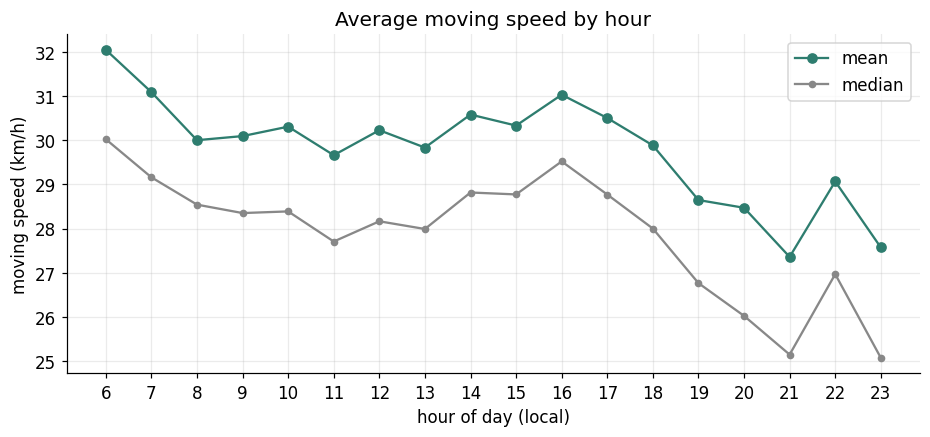

In [ ]:
spd_hr = df[valid & df["moving"]].groupby("hour")["speed_kmh"].agg(["mean", "median", "count"])
spd_hr = spd_hr[spd_hr["count"] > 200]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spd_hr.index, spd_hr["mean"], "-o", color="#2e7d6f", label="mean")
ax.plot(spd_hr.index, spd_hr["median"], "-o", color="#888", label="median", ms=4)
ax.set(xlabel="hour of day (local)", ylabel="moving speed (km/h)",
       title="Average moving speed by hour", xticks=range(6, 24))
ax.legend()
plt.show()

### 6.3 The slowest streets

Binning the network into a fine grid and colouring each cell by **median moving speed**
surfaces the chronic slow zones — the downtown core, busy junctions, and the market area —
versus the faster outer stretches.

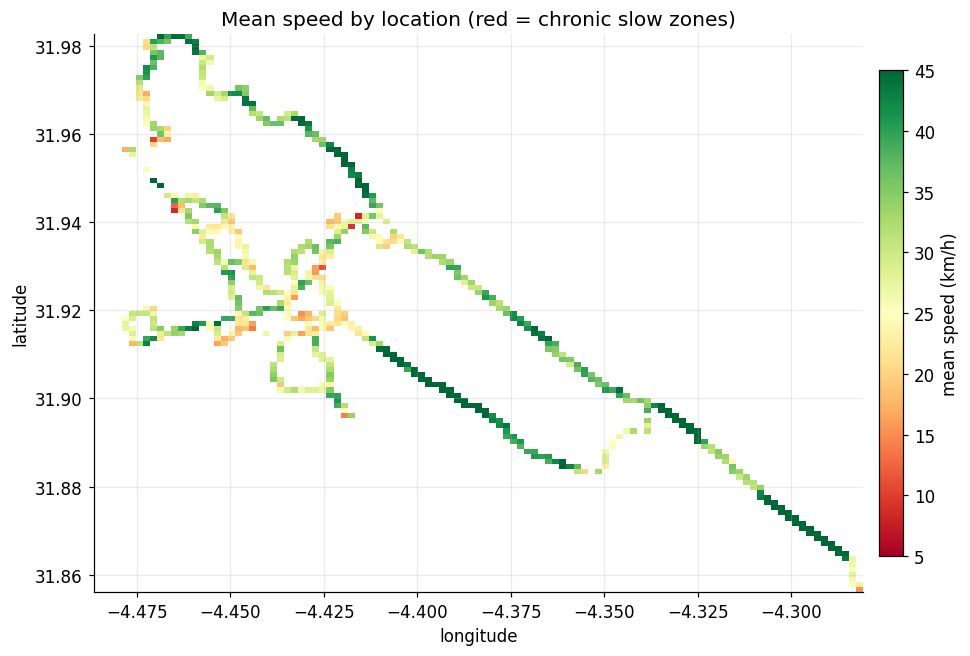

In [ ]:
mov = df[valid & df["moving"]]
nb = 110
xe = np.linspace(df["lng"].min(), df["lng"].max(), nb)
ye = np.linspace(df["lat"].min(), df["lat"].max(), nb)
sum_s, _, _ = np.histogram2d(mov["lng"], mov["lat"], bins=[xe, ye], weights=mov["speed_kmh"])
cnt, _, _ = np.histogram2d(mov["lng"], mov["lat"], bins=[xe, ye])
med = np.divide(sum_s, cnt, out=np.full_like(sum_s, np.nan), where=cnt >= 8)

fig, ax = plt.subplots(figsize=(9.5, 8))
pc = ax.pcolormesh(xe, ye, med.T, cmap="RdYlGn", vmin=5, vmax=45, shading="auto")
geo_aspect(ax, lat0)
ax.set(xlabel="longitude", ylabel="latitude",
       title="Mean speed by location (red = chronic slow zones)")
fig.colorbar(pc, ax=ax, fraction=0.03, pad=0.02, label="mean speed (km/h)")
plt.show()

## 6½ · Segmenting the stream into trips

The raw stream becomes far more useful once cut into **one-way trips**. A new trip starts
whenever the vehicle changes, the direction flag `sens` flips, or there's a time gap over
3 minutes (an outage or a long terminus layover). We then keep only segments that look like a
genuine end-to-end run — at least 3 km and 8–120 minutes — discarding fragments and
direction-flag jitter near the termini.

In [ ]:
new_trip = (
    (df["bus"] != df["bus"].shift()) |
    (df["sens"] != df["sens"].shift()) |
    (df["dt"] > 180) | df["dt"].isna()
)
df["trip_id"] = new_trip.cumsum()

# Clean per-trip distance: sum steps but ignore GPS-jump teleports.
df["clean_step"] = np.where(df["speed_kmh"] <= GPS_JUMP, df["step_m"], 0.0)

trips = (df.groupby("trip_id")
           .agg(bus=("bus", "first"), line_name=("line_name", "first"),
                sens=("sens", "first"), start=("fetched_at", "first"),
                end=("fetched_at", "last"), n=("lat", "size"),
                dist_km=("clean_step", lambda s: s.sum()/1000),
                mov_speed=("speed_kmh", lambda s: s[s.between(4, GPS_JUMP)].median()))
           .reset_index())
trips["dur_min"] = (trips["end"] - trips["start"]).dt.total_seconds() / 60
trips["start_local"] = trips["start"].dt.tz_convert(TZ_LOCAL)
trips["date"] = trips["start_local"].dt.date
trips["hour"] = trips["start_local"].dt.hour
trips["dir"] = trips["sens"].map({0: "return", 1: "outbound"})

REAL = trips[(trips["dist_km"] >= 3) & (trips["dur_min"].between(8, 120))].copy()
print(f"{len(trips):,} raw segments  ->  {len(REAL):,} clean one-way trips")
REAL.groupby(["line_name", "dir"]).size().unstack().assign(
    total=lambda t: t.sum(1))

1,331 raw segments  ->  1,221 clean one-way trips


dir,outbound,return,total
line_name,,,
L01,305,298,603
L02,118,108,226
L03,193,199,392


### Trip duration & distance

With trips in hand, the per-line travel-time and length distributions describe what a single
end-to-end ride actually looks like.

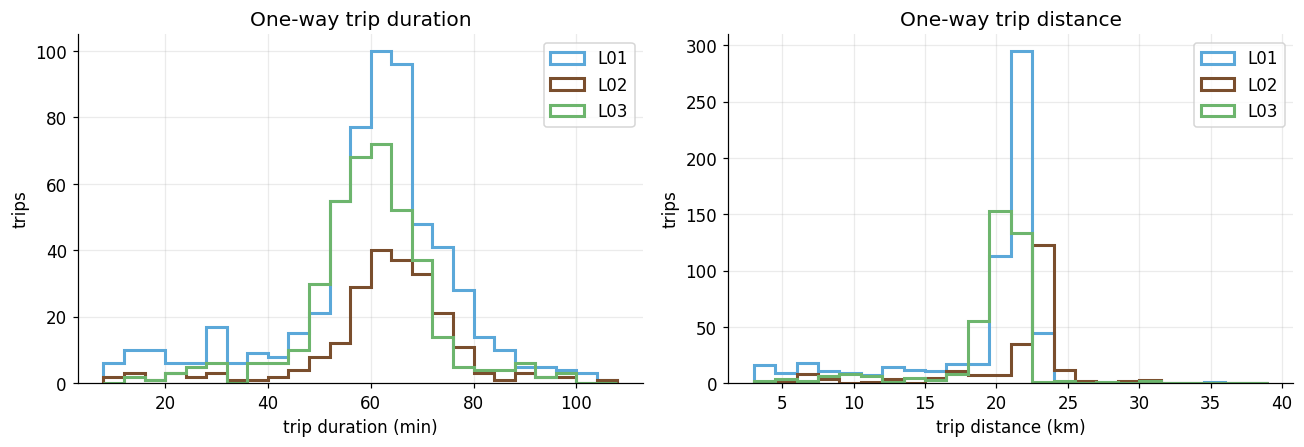

,trips,median_min,median_km,median_kmh
line_name,,,,
L01,603,61.9,21.3,29.1
L02,226,64.2,22.8,27.2
L03,392,60.1,20.3,27.7


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ln in ["L01", "L02", "L03"]:
    d = REAL[REAL["line_name"] == ln]
    axes[0].hist(d["dur_min"], bins=np.arange(8, 110, 4), histtype="step",
                 lw=2, color=LINE_COLOR[ln], label=ln)
    axes[1].hist(d["dist_km"], bins=np.arange(3, 40, 1.5), histtype="step",
                 lw=2, color=LINE_COLOR[ln], label=ln)
axes[0].set(xlabel="trip duration (min)", ylabel="trips", title="One-way trip duration")
axes[1].set(xlabel="trip distance (km)", ylabel="trips", title="One-way trip distance")
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

REAL.groupby("line_name").agg(
    trips=("dur_min", "size"),
    median_min=("dur_min", "median"),
    median_km=("dist_km", "median"),
    median_kmh=("mov_speed", "median")).round(1)

### Does the trip take longer at rush hour?

Plotting each trip's duration against its **departure hour** tests whether congestion
lengthens the same physical run during peak periods.

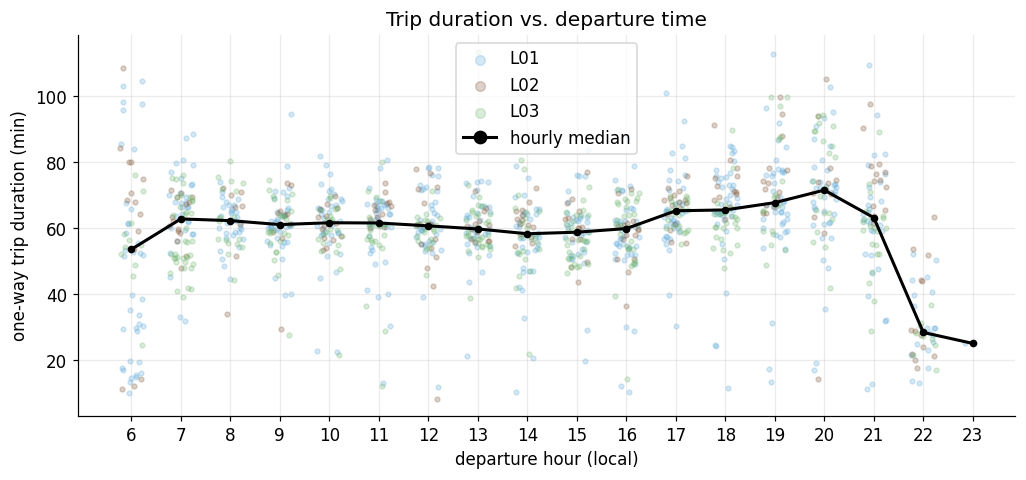

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for ln in ["L01", "L02", "L03"]:
    d = REAL[REAL["line_name"] == ln]
    jit = d["hour"] + np.random.uniform(-0.25, 0.25, len(d))
    ax.scatter(jit, d["dur_min"], s=10, alpha=0.25, color=LINE_COLOR[ln], label=ln)
hourly_med = REAL.groupby("hour")["dur_min"].median()
ax.plot(hourly_med.index, hourly_med.values, "k-o", lw=2, ms=4, label="hourly median")
ax.set(xlabel="departure hour (local)", ylabel="one-way trip duration (min)",
       title="Trip duration vs. departure time", xticks=range(6, 24))
ax.legend(markerscale=2)
plt.show()

### Daily trip counts

How many complete one-way trips the whole network turned out each day — the service-volume
heartbeat, with the outage and the Eid ramp-up both visible.

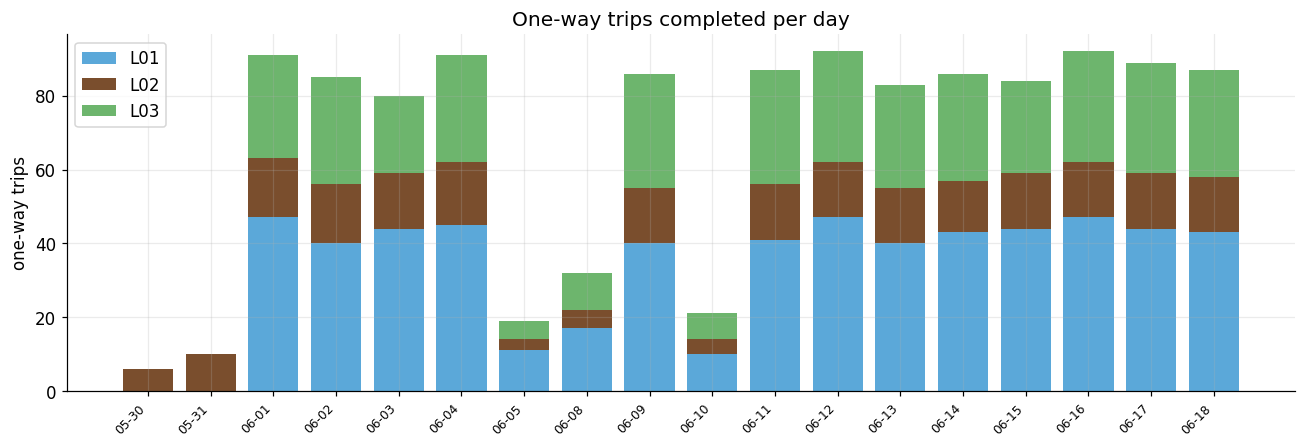

On normal-service days the network runs ~86 one-way trips/day (min 21, max 92).


In [ ]:
daily = REAL.groupby(["date", "line_name"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 4.2))
bottom = np.zeros(len(daily))
for ln in ["L01", "L02", "L03"]:
    if ln in daily:
        ax.bar(range(len(daily)), daily[ln], bottom=bottom, color=LINE_COLOR[ln], label=ln)
        bottom += daily[ln].values
ax.set(xticks=range(len(daily)), ylabel="one-way trips", title="One-way trips completed per day")
ax.set_xticklabels([d.strftime("%m-%d") for d in daily.index], rotation=45, ha="right", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

full = daily.sum(1)
full = full[full > 20]
print(f"On normal-service days the network runs ~{full.median():.0f} one-way trips/day "
      f"(min {full.min()}, max {full.max()}).")

## 7 · Service frequency (headways)

The article's premise is that "bus frequency is very low and unreliable." We can now quantify
it. Treating each trip's departure as a service event, the **headway** is the wait between
consecutive departures in the same direction on the same line, during service hours.

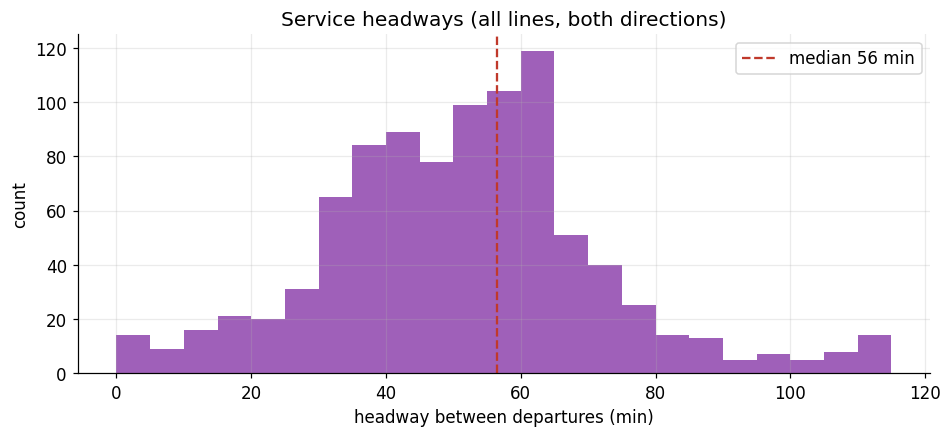

,line,dir,departures,median_min,p90_min
0,L01,outbound,288,41.8,67.6
1,L01,return,283,42.5,69.2
2,L02,outbound,99,130.6,151.1
3,L02,return,89,128.8,143.9
4,L03,outbound,177,62.3,78.8
5,L03,return,183,61.7,85.6


In [ ]:
def headways(line_name, direction):
    d = REAL[(REAL["line_name"] == line_name) & (REAL["dir"] == direction)].sort_values("start")
    h = d["start"].diff().dt.total_seconds() / 60
    # keep within-day waits only (drop overnight gaps)
    return h[(h > 0) & (h < 180)]

rows = []
for ln in ["L01", "L02", "L03"]:
    for dr in ["outbound", "return"]:
        h = headways(ln, dr)
        if len(h):
            rows.append({"line": ln, "dir": dr, "departures": len(h)+1,
                         "median_min": round(h.median(), 1),
                         "p90_min": round(h.quantile(0.9), 1)})
head_tbl = pd.DataFrame(rows)

allh = pd.concat([headways(ln, dr) for ln in ["L01","L02","L03"] for dr in ["outbound","return"]])
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(allh[allh < 120], bins=np.arange(0, 120, 5), color="#8e44ad", alpha=0.85)
ax.axvline(allh.median(), color="#c0392b", ls="--", label=f"median {allh.median():.0f} min")
ax.set(xlabel="headway between departures (min)", ylabel="count",
       title="Service headways (all lines, both directions)")
ax.legend()
plt.show()
head_tbl

The distribution confirms the lived experience: a typical wait is on the order of an hour, the
long right tail (90th percentile) is what makes it feel *unreliable*, and with one or two
vehicles per line that is essentially baked into the operating model — a bus has to drive the
full ~60-minute route and come back before it can depart again.

## 8 · Stops & layovers

### 8.1 Snapping stops to stations

Each fix is snapped to its nearest known station (an equirectangular nearest-neighbour search,
exact enough at city scale). A bus is "dwelling" at a station when it's within 70 m **and**
moving under 4 km/h. Summing those dwell seconds per station reveals where the time goes.

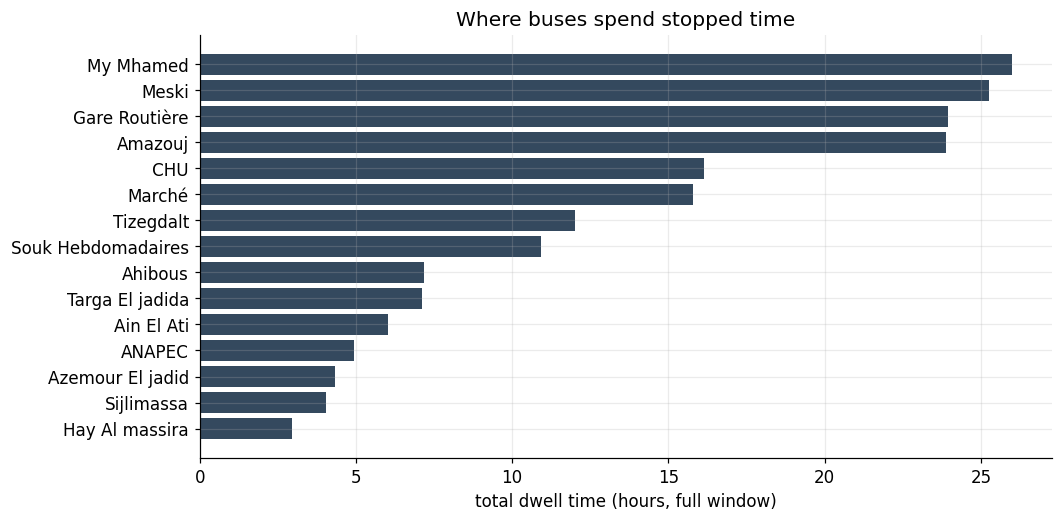

Total stationary-at-station time logged: 224 h


In [ ]:
# nearest station for every fix (vectorized, chunked)
sx = np.radians(st_lng) * np.cos(np.radians(lat0)) * EARTH_R
sy = np.radians(st_lat) * EARTH_R
px = np.radians(df["lng"].values) * np.cos(np.radians(lat0)) * EARTH_R
py = np.radians(df["lat"].values) * EARTH_R

near_i = np.empty(len(df), dtype=int)
near_d = np.empty(len(df))
CH = 20_000
for i in range(0, len(df), CH):
    dx = px[i:i+CH, None] - sx[None, :]
    dy = py[i:i+CH, None] - sy[None, :]
    dist = np.hypot(dx, dy)
    near_i[i:i+CH] = dist.argmin(1)
    near_d[i:i+CH] = dist.min(1)

st_names = [s["name"] for s in stations]
df["near_station"] = [st_names[i] for i in near_i]
df["near_m"] = near_d
df["at_stop"] = (df["near_m"] < 70) & (df["dt"].between(0, 60)) & (df["speed_kmh"] < 4)

dwell = (df[df["at_stop"]].groupby("near_station")["dt"].sum() / 3600).sort_values(ascending=False)
top = dwell.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top.index[::-1], top.values[::-1], color="#34495e")
ax.set(xlabel="total dwell time (hours, full window)", title="Where buses spend stopped time")
plt.show()
print(f"Total stationary-at-station time logged: {df.loc[df['at_stop'],'dt'].sum()/3600:.0f} h")

The ranking is dominated by **termini** (My Mhamed, Meski, Amazouj, Tizegdalt, Ahibous) where
buses lay over between runs, followed by genuine hubs — **Gare Routière** (the bus station),
**Marché** (market) and **CHU** (hospital). That matches how the network actually behaves:
most "stopped" time is layover at the ends, not boarding time mid-route.

### 8.2 Stop episodes: layovers vs. boarding

Grouping consecutive *stationary-at-the-same-station* fixes into **stop episodes** separates
two very different behaviours: long **terminus layovers** (recovery time before a vehicle
turns around) from short **mid-route stops** (passengers boarding). The contrast is stark.

(Episode durations are a lower bound — a momentary GPS speed blip can split one long layover
into two — but the two populations are cleanly distinct.)

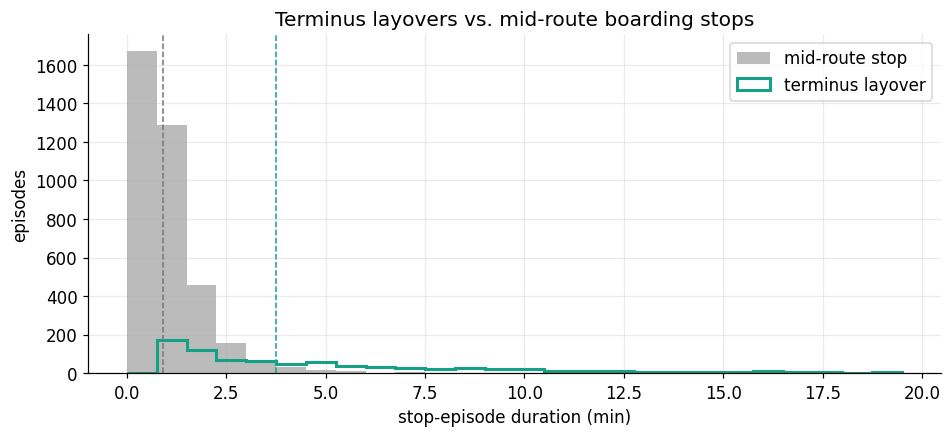

terminus layover : median 3.7 min  (p75 7.6),  n=841
mid-route stop   : median 0.9 min  (p75 1.4),  n=3715


In [ ]:
TERMINI = {"Amazouj", "Meski", "Omrane", "Ahibous", "My Mhamed", "Tizegdalt"}

# A new episode starts on: vehicle change, nearest-station change,
# stopped<->moving transition, or a >2-min time gap.
brk = ((df["bus"] != df["bus"].shift()) |
       (df["near_station"] != df["near_station"].shift()) |
       (df["at_stop"] != df["at_stop"].shift()) |
       (df["dt"] > 120) | df["dt"].isna())
df["episode"] = brk.cumsum()

ep = (df[df["at_stop"]].groupby("episode")
        .agg(station=("near_station", "first"), bus=("bus", "first"),
             start=("fetched_at", "first"), end=("fetched_at", "last"))
        .reset_index())
ep["dur_min"] = (ep["end"] - ep["start"]).dt.total_seconds() / 60
ep = ep[ep["dur_min"] >= 0.5]
ep["kind"] = np.where(ep["station"].isin(TERMINI), "terminus layover", "mid-route stop")

term = ep[(ep["kind"] == "terminus layover") & ep["dur_min"].between(1, 60)]
mid  = ep[(ep["kind"] == "mid-route stop") & ep["dur_min"].between(0.5, 15)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mid["dur_min"], bins=np.arange(0, 20, 0.75), color="#bbb", label="mid-route stop")
ax.hist(term["dur_min"], bins=np.arange(0, 20, 0.75), histtype="step", lw=2,
        color="#16a085", label="terminus layover")
ax.axvline(term["dur_min"].median(), color="#16a085", ls="--", lw=1)
ax.axvline(mid["dur_min"].median(), color="#777", ls="--", lw=1)
ax.set(xlabel="stop-episode duration (min)", ylabel="episodes",
       title="Terminus layovers vs. mid-route boarding stops")
ax.legend()
plt.show()

print(f"terminus layover : median {term['dur_min'].median():.1f} min  (p75 {term['dur_min'].quantile(.75):.1f}),  n={len(term)}")
print(f"mid-route stop   : median {mid['dur_min'].median():.1f} min  (p75 {mid['dur_min'].quantile(.75):.1f}),  n={len(mid)}")

## 9 · Fleet operations

### 9.1 Vehicle ↔ line assignment

Each physical bus is mostly faithful to one line, but not entirely — a couple of vehicles get
borrowed across lines. The table below is the share of each vehicle's sightings per line.

In [ ]:
assign = pd.crosstab(df["bus"], df["line_name"], normalize="index").mul(100).round(1)
assign["primary"] = assign.idxmax(1)
assign["sightings"] = df.groupby("bus").size()
assign

line_name,L01,L02,L03,primary,sightings
bus,,,,,
12101,0.0,0.0,100.0,L03,66280
12201,100.0,0.0,0.0,L01,71394
12202,99.8,0.2,0.0,L01,71007
12203,1.7,98.3,0.0,L02,77871
12301,100.0,0.0,0.0,L01,62470
12304,0.0,0.0,100.0,L03,67530


Vehicles **12203** and **12202** are the swing units — 12203 is normally the L02 bus but spent
time on L01, and 12202 is the reverse. The rest are dedicated. This is the kind of operational
detail the official app never exposes but that falls straight out of the logs.

### 9.2 Per-vehicle workload

Daily distance per vehicle (clean, GPS-jumps removed) measures how hard each bus is worked
once full service is running.

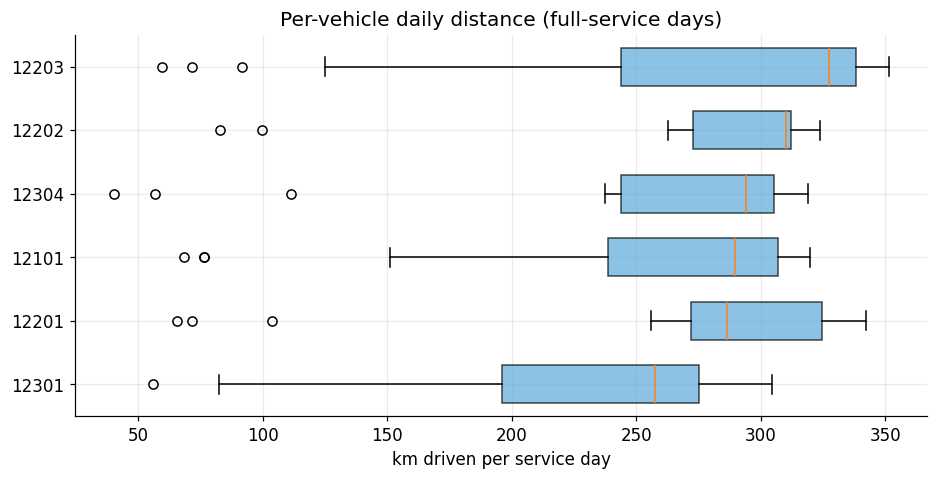

Fleet covers ~1753 km on a full day; ~24,770 km logged across the whole window.


In [ ]:
df["clean_km"] = df["clean_step"] / 1000
veh_day = (df[df["dt"].between(0, 60)]
           .groupby(["bus", "date"])["clean_km"].sum().reset_index())
veh_day = veh_day[veh_day["clean_km"] > 20]  # full-service days only

order = veh_day.groupby("bus")["clean_km"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
data = [veh_day[veh_day["bus"] == b]["clean_km"].values for b in order]
bp = ax.boxplot(data, vert=False, tick_labels=list(order), patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor("#5BA8D9"); patch.set_alpha(0.7)
ax.set(xlabel="km driven per service day", title="Per-vehicle daily distance (full-service days)")
plt.show()

print(f"Fleet covers ~{veh_day.groupby('date')['clean_km'].sum().median():.0f} km on a full day; "
      f"~{df['clean_km'].sum():,.0f} km logged across the whole window.")

## 10 · Key takeaways

Pulling the threads together — everything below is derived purely from a timestamp and a
`lat/lng` sampled every ~10 seconds:

- **Collection held up.** ~115 k polls at a steady 10–15 s cadence, GPS fixes a median ~5 s
  old, with effectively one multi-day outage. Clean enough to trust the rest.
- **A clean daily clock.** Service runs ~06:00–23:00 local, six vehicles at full deployment,
  and the window captures the **Eid → normal-service** transition: a lone bus on L02 giving
  way to the full three-line fleet.
- **The map is in the data.** The three routes, their shared downtown trunk, the terminus
  stubs, and the chronic slow zones (downtown, the market, key junctions) all reconstruct from
  raw pings — no basemap required.
- **An hour between buses.** One-way trips run ~60 minutes / ~22 km at ~20 km/h moving speed;
  with one or two vehicles per line the headway is ~an hour with a heavy tail — the "low and
  unreliable" reputation, quantified.
- **Time goes to the ends.** Stop episodes split cleanly: ~4-minute median terminus layovers
  vs. roughly one-minute mid-route boarding stops. Most stationary time is recovery at the
  termini; Gare Routière, Marché and CHU are the busiest non-terminus stops.
- **Operations leak through.** Vehicle↔line assignments, two swing buses, and per-vehicle daily
  mileage all surface from the log.

The natural next step — flagged in the article — is **arrival-time prediction**. The trip and
segment travel-times extracted here, conditioned on hour-of-day and direction, are exactly the
training signal a model would need to beat the app's opaque ETAs. That's a notebook for another
day.